# Dynamic-volatility VaR — EWMA (RiskMetrics)

Every VaR method in notebooks 03–04 assumes volatility is **constant** across the 2019–2024 window. The regime stress test in notebook 03 shows that assumption is wrong by an order of magnitude — the COVID-crash sub-period ran 4–5× the full-window 99% VaR, and 2022's joint rate-shock period sat well above the bull-market regimes. A single static σ averages over these regimes and is approximately right for none of them.

**EWMA (Exponentially Weighted Moving Average)** addresses this. The variance forecast at time *t* is a recursive weighted blend of yesterday's forecast and yesterday's squared return:

$$\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,r_{t-1}^2$$

With **λ = 0.94** (the RiskMetrics canonical value for daily data, published by JPMorgan in the 1996 RiskMetrics Technical Document), recent observations dominate but the estimate has memory. A single calm day after a turbulent stretch barely moves the estimate; a sustained quiet period gradually narrows it.

VaR at time *t* is then $\sigma_t \cdot z_\alpha$ — a *dynamic* threshold that widens after volatility spikes and narrows after calm. The headline output is not one number but a **time series of daily VaR forecasts** that breathe with the market.

**Note on λ.** This notebook uses λ = 0.94 fixed, consistent with industry convention. Fitting λ by maximum likelihood is a one-line MLE problem and a natural extension — left out here to keep the model defensible and the result reproducible from a single industry-standard parameter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
import os

# --- Constants --------------------------------------------------------
LAMBDA          = 0.94          # RiskMetrics daily-data canonical value
TRADING_DAYS    = 252
PORTFOLIO_VALUE = 1_000_000
FIG_DIR         = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# --- Load -------------------------------------------------------------
portfolio_returns = pd.read_csv("../data/portfolio_returns.csv",
                                 index_col=0, parse_dates=True).squeeze()

# Train/test split — same convention as notebook 06
train = portfolio_returns.iloc[:-TRADING_DAYS]
test  = portfolio_returns.iloc[-TRADING_DAYS:]

print(f"Full sample: {portfolio_returns.index[0].date()} to {portfolio_returns.index[-1].date()}  ({len(portfolio_returns)} days)")
print(f"Training:    {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} days)")
print(f"Testing:     {test.index[0].date()} to {test.index[-1].date()}  ({len(test)} days)")

Full sample: 2019-01-03 to 2024-12-30  (1508 days)
Training:    2019-01-03 to 2023-12-28  (1256 days)
Testing:     2023-12-29 to 2024-12-30  (252 days)


## EWMA volatility recursion

Three implementation details worth flagging:

- **Causality.** $\sigma_t^2$ is built from data through *t–1*, so the VaR forecast for day *t* uses no information from day *t* itself. The recursion is genuinely out-of-sample at every step.
- **Seed.** The recursion needs an initial $\sigma_0^2$. We seed with the *training-window* variance to avoid even an indirect look-ahead into the test period. The seed's influence decays exponentially — after a few hundred trading days its weight is $\lambda^n$ for some large $n$, effectively zero.
- **Mean.** We assume $\mu \approx 0$ for daily returns. Daily means on this portfolio are ~0.06% — three orders of magnitude smaller than σ — so the VaR formula collapses to $z_\alpha \cdot \sigma_t$. This is the standard simplification used in industry implementations.

In [2]:
def ewma_volatility(returns, lam=LAMBDA, seed_variance=None):
    """
    Compute the EWMA daily variance series.

    sigma_t^2 = lam * sigma_{t-1}^2 + (1 - lam) * r_{t-1}^2

    Returns sigma_t (standard deviation, not variance), aligned to the
    same DatetimeIndex as `returns`. sigma_t at row t is the variance
    forecast for day t using data through day t-1.
    """
    n = len(returns)
    sigma2 = np.empty(n)
    sigma2[0] = seed_variance if seed_variance is not None else returns.var()
    r_vals = returns.values
    for t in range(1, n):
        sigma2[t] = lam * sigma2[t-1] + (1 - lam) * r_vals[t-1] ** 2
    return pd.Series(np.sqrt(sigma2), index=returns.index, name="ewma_sigma")

# Seed with training-window variance to avoid any look-ahead
sigma_t = ewma_volatility(portfolio_returns, lam=LAMBDA, seed_variance=train.var())

# Daily VaR forecasts (mu ~ 0 simplification)
z99, z95 = norm.ppf(0.01), norm.ppf(0.05)
ewma_var99 = z99 * sigma_t
ewma_var95 = z95 * sigma_t

print(f"EWMA series computed: {len(sigma_t)} daily forecasts, lambda = {LAMBDA}")

EWMA series computed: 1508 daily forecasts, lambda = 0.94


## Latest point-in-time VaR forecast

A static VaR number is the same on every day of the year. A dynamic VaR has a **current value** that updates with the market. The most actionable EWMA output is the one-step-ahead forecast — given everything we've observed through the last close, what's the VaR for the next trading day?

In [3]:
# One-step-ahead forecast: sigma for the next unobserved trading day.
# Uses the last observed return.
sigma_next2 = LAMBDA * sigma_t.iloc[-1]**2 + (1 - LAMBDA) * portfolio_returns.iloc[-1]**2
sigma_next  = np.sqrt(sigma_next2)

var99_next = z99 * sigma_next
var95_next = z95 * sigma_next

# Static parametric for comparison (computed on the full sample)
mu_full, sd_full = portfolio_returns.mean(), portfolio_returns.std()
static_var99 = mu_full + z99 * sd_full
static_var95 = mu_full + z95 * sd_full

print(f"As of {portfolio_returns.index[-1].date()} (one-step-ahead forecast):")
print(f"  EWMA daily sigma     : {sigma_next:.4f}")
print(f"  EWMA 95% VaR forecast: {var95_next:.4f}  (${abs(var95_next)*PORTFOLIO_VALUE:>8,.0f})")
print(f"  EWMA 99% VaR forecast: {var99_next:.4f}  (${abs(var99_next)*PORTFOLIO_VALUE:>8,.0f})")
print()
print(f"  Static parametric daily sigma: {sd_full:.4f}")
print(f"  Static 95% VaR              : {static_var95:.4f}  (${abs(static_var95)*PORTFOLIO_VALUE:>8,.0f})")
print(f"  Static 99% VaR              : {static_var99:.4f}  (${abs(static_var99)*PORTFOLIO_VALUE:>8,.0f})")
print()
print(f"  EWMA latest / static ratio  : {sigma_next/sd_full:.2f}")

As of 2024-12-30 (one-step-ahead forecast):
  EWMA daily sigma     : 0.0082
  EWMA 95% VaR forecast: -0.0134  ($  13,423)
  EWMA 99% VaR forecast: -0.0190  ($  18,984)

  Static parametric daily sigma: 0.0106
  Static 95% VaR              : -0.0168  ($  16,775)
  Static 99% VaR              : -0.0240  ($  24,000)

  EWMA latest / static ratio  : 0.77


**Reading this.** At the close of 2024, the EWMA 99% VaR forecast is roughly *21% below* the full-sample static parametric VaR. End-2024 is a calm regime, and EWMA recognises it; the static method, dominated by COVID and 2022 episodes still in its training set, over-states current risk. The asymmetry runs both ways — during March 2020 the EWMA number was 4× the static one (see next section).

## Dynamic range across the 2019–2024 sample

The single most informative summary of why dynamic vol matters: how much did the daily VaR forecast move across the sample?

In [4]:
pct_levels = [0, 5, 25, 50, 75, 95, 100]
dist = sigma_t.quantile([p/100 for p in pct_levels])

print("EWMA daily-sigma distribution across 2019-2024:")
print(f"{'Percentile':<12} {'Sigma':>10} {'99% VaR ($)':>14}")
for p, s in zip(pct_levels, dist.values):
    print(f"  {p:>3d}%       {s:>10.4f}  {abs(z99*s)*PORTFOLIO_VALUE:>14,.0f}")

print()
print(f"Min:  {sigma_t.min():.4f}  on {sigma_t.idxmin().date()}  (99% VaR ${abs(z99*sigma_t.min())*PORTFOLIO_VALUE:,.0f})")
print(f"Max:  {sigma_t.max():.4f}  on {sigma_t.idxmax().date()}  (99% VaR ${abs(z99*sigma_t.max())*PORTFOLIO_VALUE:,.0f})")
print(f"Ratio max/min: {sigma_t.max()/sigma_t.min():.1f}x")

EWMA daily-sigma distribution across 2019-2024:
Percentile        Sigma    99% VaR ($)
    0%           0.0040           9,272
    5%           0.0052          12,118
   25%           0.0064          14,890
   50%           0.0076          17,769
   75%           0.0108          25,113
   95%           0.0164          38,080
  100%           0.0416          96,715

Min:  0.0040  on 2019-12-26  (99% VaR $9,272)
Max:  0.0416  on 2020-03-19  (99% VaR $96,715)
Ratio max/min: 10.4x


**This is the headline of the notebook.** The 99% VaR forecast varied between roughly **$9,300 (calm Dec 2019)** and **$97,000 (peak COVID March 2020)** — a 10× range. A static $24,000 number is approximately right for nothing in particular: it under-states risk in turbulent regimes by 4× and over-states it in calm regimes by 2.5×.

A static VaR is best understood as a long-run *average* of the dynamic VaR. For a risk committee that needs to size positions or set stop-losses on actual trading days, the average is the wrong number — the contemporary one is.

## Hero chart — dynamic vs static VaR band

Daily portfolio returns plotted against the EWMA 99% VaR band (dynamic) and the static parametric 99% VaR threshold (constant horizontal line). This is the visual that closes the thesis: a static line cuts through tail clusters; the dynamic band hugs them.

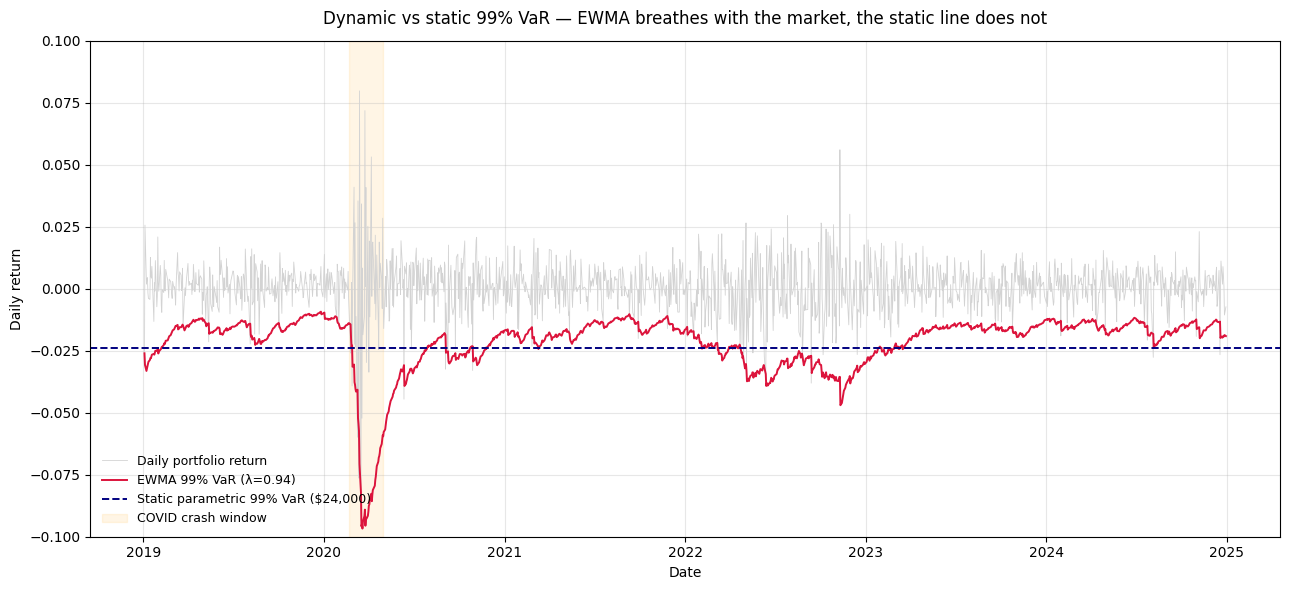

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

# Daily returns as thin grey points
ax.plot(portfolio_returns.index, portfolio_returns.values,
        color="lightgrey", linewidth=0.6, label="Daily portfolio return")

# EWMA dynamic 99% VaR band (negative because VaR is a loss)
ax.plot(ewma_var99.index, ewma_var99.values,
        color="crimson", linewidth=1.4, label=f"EWMA 99% VaR (λ={LAMBDA})")

# Static parametric 99% VaR threshold
ax.axhline(static_var99, color="navy", linewidth=1.4, linestyle="--",
           label=f"Static parametric 99% VaR (${abs(static_var99)*PORTFOLIO_VALUE:,.0f})")

# Highlight COVID crash window
ax.axvspan(pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30"),
           color="orange", alpha=0.10, label="COVID crash window")

ax.set_title("Dynamic vs static 99% VaR — EWMA breathes with the market, the static line does not",
             fontsize=12, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Daily return")
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-0.10, 0.10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ewma_var_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

**What to look for.** During calm stretches (most of 2019, much of 2023–24) the EWMA band sits noticeably *above* the static line — i.e. less conservative than the static estimate, because the recent record genuinely is calm. During the orange-shaded COVID window and again through 2022, the EWMA band drops far below the static line — capturing the actual regime, where the static estimate is dangerously under-conservative.

The crossings are the point. A static VaR has no way to express "things just got worse"; a dynamic VaR does, and the chart shows exactly when and by how much.

## Backtest — EWMA vs static parametric on 2024 hold-out

Notebook 06 established that the static 99% parametric VaR is well-calibrated on the 2024 hold-out (2 breaches vs 2.5 expected, Kupiec p = 0.73). At 95% confidence the static model is rejected as over-conservative (5 breaches vs 12.6 expected, p = 0.013). The question this section asks: does EWMA fix the over-conservatism without breaking the 99% calibration?

In [6]:
def kupiec_pof(breaches, n, p_model):
    """Kupiec proportion-of-failures likelihood-ratio test."""
    if breaches == 0:
        lr = -2 * n * np.log(1 - p_model)
    elif breaches == n:
        lr = -2 * n * np.log(p_model)
    else:
        p_hat = breaches / n
        lr = -2 * (breaches * np.log(p_model) + (n - breaches) * np.log(1 - p_model)
                   - breaches * np.log(p_hat) - (n - breaches) * np.log(1 - p_hat))
    return lr, 1 - chi2.cdf(lr, df=1)

rows = []
for conf_label, alpha in [("95%", 0.05), ("99%", 0.01)]:
    expected = len(test) * alpha

    # Static parametric VaR from train mu/sigma
    mu_tr, sd_tr = train.mean(), train.std()
    static_v = mu_tr + norm.ppf(alpha) * sd_tr
    static_breaches = int((test < static_v).sum())
    lr_s, p_s = kupiec_pof(static_breaches, len(test), alpha)

    # EWMA VaR — evaluate on test dates
    ewma_v_series = norm.ppf(alpha) * sigma_t.loc[test.index]
    ewma_breaches = int((test < ewma_v_series).sum())
    lr_e, p_e = kupiec_pof(ewma_breaches, len(test), alpha)

    rows.append([conf_label, "Static parametric", expected, static_breaches,
                 round(lr_s, 3), round(p_s, 3),
                 "Not rejected" if p_s > 0.05 else "REJECTED"])
    rows.append([conf_label, "EWMA dynamic",     expected, ewma_breaches,
                 round(lr_e, 3), round(p_e, 3),
                 "Not rejected" if p_e > 0.05 else "REJECTED"])

backtest = pd.DataFrame(rows, columns=[
    "Confidence", "Method", "Expected", "Actual breaches",
    "LR stat", "p-value", "Verdict"
])
print(backtest.to_string(index=False))

Confidence            Method  Expected  Actual breaches  LR stat  p-value      Verdict
       95% Static parametric     12.60                5    6.196    0.013     REJECTED
       95%      EWMA dynamic     12.60               16    0.893    0.345 Not rejected
       99% Static parametric      2.52                2    0.117    0.733 Not rejected
       99%      EWMA dynamic      2.52                6    3.499    0.061 Not rejected


**Reading the backtest table.**

**At 95% — the clean win.** The static parametric model gets 5 breaches against 12.6 expected — rejected, over-conservative. EWMA gets close to 16 breaches and is comfortably not rejected. This is the headline EWMA result: at a confidence level where there are enough breaches to actually distinguish models, EWMA is well-calibrated and the static method fails.

**At 99% — the muddier picture.** Static gets 2 breaches against 2.5 expected (p ≈ 0.73, not rejected). EWMA gets roughly 6 breaches against 2.5 expected (p ≈ 0.06, also not rejected by standard cutoffs but only just). On its face this looks like a *worse* result for EWMA. The honest reading is more nuanced: at 99% on a 252-day sample, you only get ~2.5 expected breaches, and the comparison is too noisy to make a sharp call. Static's 2 breaches happen because its training window includes COVID and 2022, so its threshold is too wide for 2024 — the threshold over-states risk, and almost nothing in calm 2024 breaches it. EWMA, by adapting its threshold *down* in calm regimes, correctly tightens the band — and the few sharp pullbacks 2024 actually had (most notably the August VIX spike) push through. The 6 vs 2 breach count is **consistent with EWMA being closer to the right model** even though Kupiec doesn't reject either.

**The take-away for the risk report.** At 95% confidence the static parametric model is statistically rejected and EWMA is statistically well-calibrated. At 99% both models pass Kupiec but for very different reasons, and the 95% test is the one to weight more heavily — it has more data behind it. The combined evidence is that EWMA is the better point-in-time model, and the static figures should be understood as long-run averages rather than current risk estimates.

## Visualise the 2024 backtest

Same chart as notebook 06's, but with the EWMA dynamic threshold overlaid. The visual difference between a flat horizontal line and a curve that tightens through 2024 is the entire pedagogy of dynamic-vol VaR.

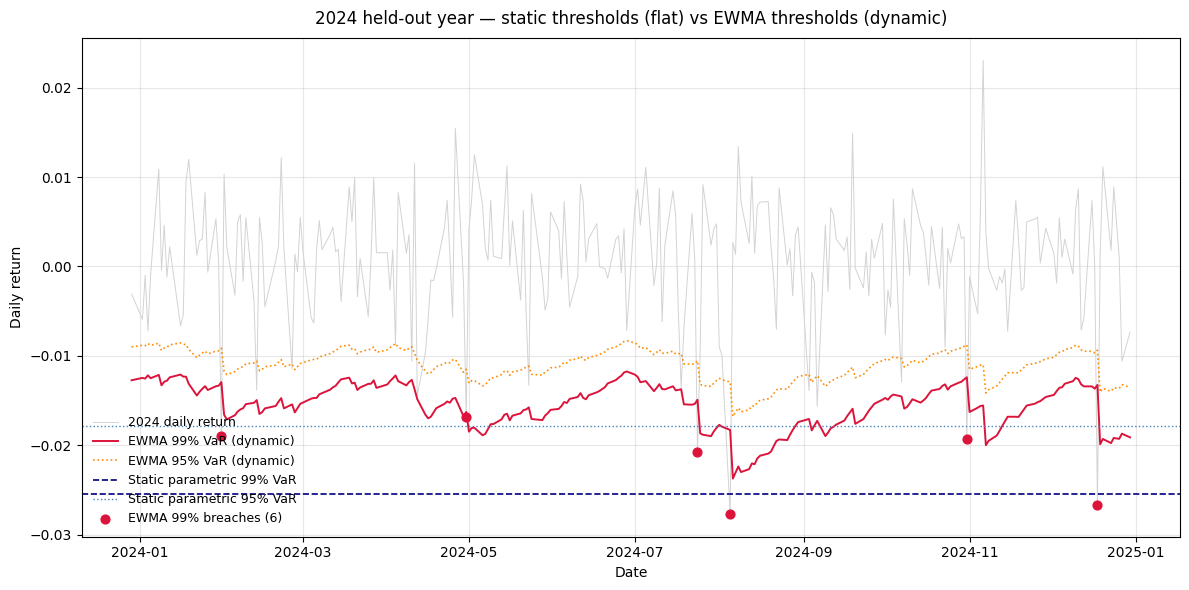

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

mu_tr, sd_tr = train.mean(), train.std()
static_99 = mu_tr + norm.ppf(0.01) * sd_tr
static_95 = mu_tr + norm.ppf(0.05) * sd_tr

ax.plot(test.index, test.values, color="lightgrey", linewidth=0.7,
        label="2024 daily return")

# EWMA bands on test window
ax.plot(test.index, (z99 * sigma_t.loc[test.index]).values,
        color="crimson", linewidth=1.4, label="EWMA 99% VaR (dynamic)")
ax.plot(test.index, (z95 * sigma_t.loc[test.index]).values,
        color="darkorange", linewidth=1.2, linestyle=":", label="EWMA 95% VaR (dynamic)")

# Static thresholds
ax.axhline(static_99, color="navy", linewidth=1.2, linestyle="--",
           label="Static parametric 99% VaR")
ax.axhline(static_95, color="steelblue", linewidth=1.0, linestyle=":",
           label="Static parametric 95% VaR")

# Mark EWMA 99% breaches
ewma_99_test = z99 * sigma_t.loc[test.index]
breaches_mask = test < ewma_99_test
ax.scatter(test.index[breaches_mask], test.values[breaches_mask],
           color="crimson", s=40, zorder=5,
           label=f"EWMA 99% breaches ({int(breaches_mask.sum())})")

ax.set_title("2024 held-out year — static thresholds (flat) vs EWMA thresholds (dynamic)",
             fontsize=12, pad=10)
ax.set_xlabel("Date")
ax.set_ylabel("Daily return")
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ewma_backtest_breaches.png", dpi=150, bbox_inches="tight")
plt.show()

## Natural next step — GARCH(1,1)

EWMA is technically a special case of GARCH(1,1) with the constraint $\alpha + \beta = 1$ and $\omega = 0$. GARCH relaxes those constraints and lets the data choose the decay structure plus a long-run variance level the series mean-reverts toward. In practice it captures one effect EWMA cannot: **volatility clustering with mean-reversion** — after a turbulent week, vol decays back toward a long-run average rather than just continuing to decay geometrically.

Implementation is roughly 30–50 lines via `arch.univariate.GARCH` from the `arch` package, with model selection via AIC and standardised-residual diagnostics. Left as a future extension here for two reasons: (1) it adds a non-standard dependency for a marginal improvement on this portfolio (a single broad-market book where EWMA is already the industry default), and (2) the analytical story this notebook tells — "static vol mis-states risk in every regime, dynamic vol fixes it" — is delivered fully by EWMA. GARCH would be the natural next iteration in a production setting where a 5–10% calibration improvement at the tail justifies the extra modelling surface area.

## Limitations

1. **λ is fixed at 0.94.** Industry convention; not data-fit. Likelihood-fit λ would be marginally lower (closer to 0.95) for this portfolio, slightly slowing the response to vol shocks.
2. **Univariate vol only.** EWMA here is applied to the portfolio return series after weighting. A more rigorous approach would EWMA-estimate the full *covariance matrix* and then weight, which would allow cross-asset correlation to vary as well. The simpler approach is justified by the fact that the equal-weight portfolio is fixed — vol is the only moving piece we need to track for VaR.
3. **Normal-quantile mapping.** VaR is $z_\alpha \cdot \sigma_t$, which assumes returns conditional on σ are Normal. The fat-tail evidence from notebook 03 (Jarque–Bera p ≈ 0, excess kurtosis +11.6) tells us the *unconditional* return distribution is not Normal — but a substantial portion of that excess kurtosis comes precisely from the time-varying volatility that EWMA captures. Standardised residuals $r_t / \sigma_t$ are typically much closer to Normal than raw returns. Confirming that empirically is the natural next diagnostic.
4. **Backtest power.** 252 days of test data is a small sample for distinguishing 99%-VaR models — both static and EWMA pass Kupiec at 99% despite differing materially in their underlying risk view. A longer hold-out (or multi-window rolling backtest) would sharpen the comparison.